# EDA LOAN

In [37]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import style

import seaborn as sns

%matplotlib inline

In [38]:
import warnings
warnings.filterwarnings("ignore")

style.use('ggplot') or plt.style.use('ggplot')

In [39]:
df_loan = pd.read_csv('https://raw.githubusercontent.com/SonikoKatsura/CURSO_PARO_IA/refs/heads/main/Rober_IA/Modulo1/datos/data_loan.csv')

df_loan.sample(n=6)

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Annual Income,Years in current job,Home Ownership,Number of Open Accounts,Number of Credit Problems,Bankruptcies
92548,54525363-fb24-44dc-8f0c-a9eb0ce404d5,02f5b9b0-60f3-4489-8d31-35a3b5925b4e,Fully Paid,99999999.0,1311114.0,NaN,Home Mortgage,10.0,0.0,0.0
2673,50e9578a-73e0-4aaa-a6b1-cba416b944d4,05f83e78-08ed-4ee8-8270-fc6ce3bfdb87,Fully Paid,99999999.0,1399179.0,2 years,Home Mortgage,8.0,0.0,0.0
97838,dad9763a-278e-4cfd-b239-fce55c97d307,0dc8b3ca-be0b-4045-b20f-a809fd208f63,Charged Off,760760.0,2721940.0,8 years,Home Mortgage,25.0,0.0,0.0
58759,8a6217d4-5fa3-4240-8a13-1b42f06e63cd,055da8e6-fd68-4ab5-9b3e-8d1c862a37a5,Fully Paid,136532.0,2181827.0,8 years,Home Mortgage,15.0,0.0,0.0
70428,33ec13e4-d9fc-43b2-8ce8-054e493ae70f,1eb60334-f305-410a-bb81-c2182983288c,Fully Paid,99999999.0,2044647.0,< 1 year,Rent,20.0,0.0,0.0
12112,e4fbbcf9-2eb0-4f09-bc0c-cb51df2fce5b,77ce1891-b01e-4260-9f27-83b2f0c1ab18,Charged Off,769362.0,2233887.0,10+ years,Home Mortgage,7.0,0.0,0.0


In [40]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Loan ID                    100000 non-null  object 
 1   Customer ID                100000 non-null  object 
 2   Loan Status                100000 non-null  object 
 3   Current Loan Amount        100000 non-null  float64
 4   Annual Income              80846 non-null   float64
 5   Years in current job       95778 non-null   object 
 6   Home Ownership             100000 non-null  object 
 7   Number of Open Accounts    100000 non-null  float64
 8   Number of Credit Problems  100000 non-null  float64
 9   Bankruptcies               99796 non-null   float64
dtypes: float64(5), object(5)
memory usage: 7.6+ MB


#### Eliminar campos ID por no necesarios

In [41]:
df_loan.drop(columns=['Loan ID', 'Customer ID'], inplace=True)

#### Cambio nombre columnas (sin espacios)

In [42]:
df_loan.columns = [columna.replace(' ','_') for columna in df_loan.columns.to_list()]

df_loan.columns

Index(['Loan_Status', 'Current_Loan_Amount', 'Annual_Income',
       'Years_in_current_job', 'Home_Ownership', 'Number_of_Open_Accounts',
       'Number_of_Credit_Problems', 'Bankruptcies'],
      dtype='object')

In [43]:
df_loan.describe()

,Current_Loan_Amount,Annual_Income,Number_of_Open_Accounts,Number_of_Credit_Problems,Bankruptcies
count,1.000000e+05,8.084600e+04,100000.00000,100000.000000,99796.000000
mean,1.176045e+07,1.378277e+06,11.12853,0.168310,0.117740
std,3.178394e+07,1.081360e+06,5.00987,0.482705,0.351424
min,1.080200e+04,7.662700e+04,0.00000,0.000000,0.000000
25%,1.796520e+05,8.488440e+05,8.00000,0.000000,0.000000
50%,3.122460e+05,1.174162e+06,10.00000,0.000000,0.000000
75%,5.249420e+05,1.650663e+06,14.00000,0.000000,0.000000
max,1.000000e+08,1.655574e+08,76.00000,15.000000,7.000000


In [44]:
df_loan.describe(include='object')

,Loan_Status,Years_in_current_job,Home_Ownership
count,100000,95778,100000
unique,2,11,4
top,Fully Paid,10+ years,Home Mortgage
freq,77361,31121,48410


In [45]:
df_loan.duplicated().sum()

np.int64(10246)

#### Eliminamos duplicados

In [46]:
df_loan.drop_duplicates(inplace=True)

In [47]:
var_num = df_loan.select_dtypes(exclude='object').columns.to_list()

var_cat = df_loan.select_dtypes(include='object').columns.to_list()


## ANALISIS UNIDIMENSIONAL

In [48]:
# valores colormap
TABLEAU_CMP = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', \
               'tab:gray','tab:olive', 'tab:cyan')

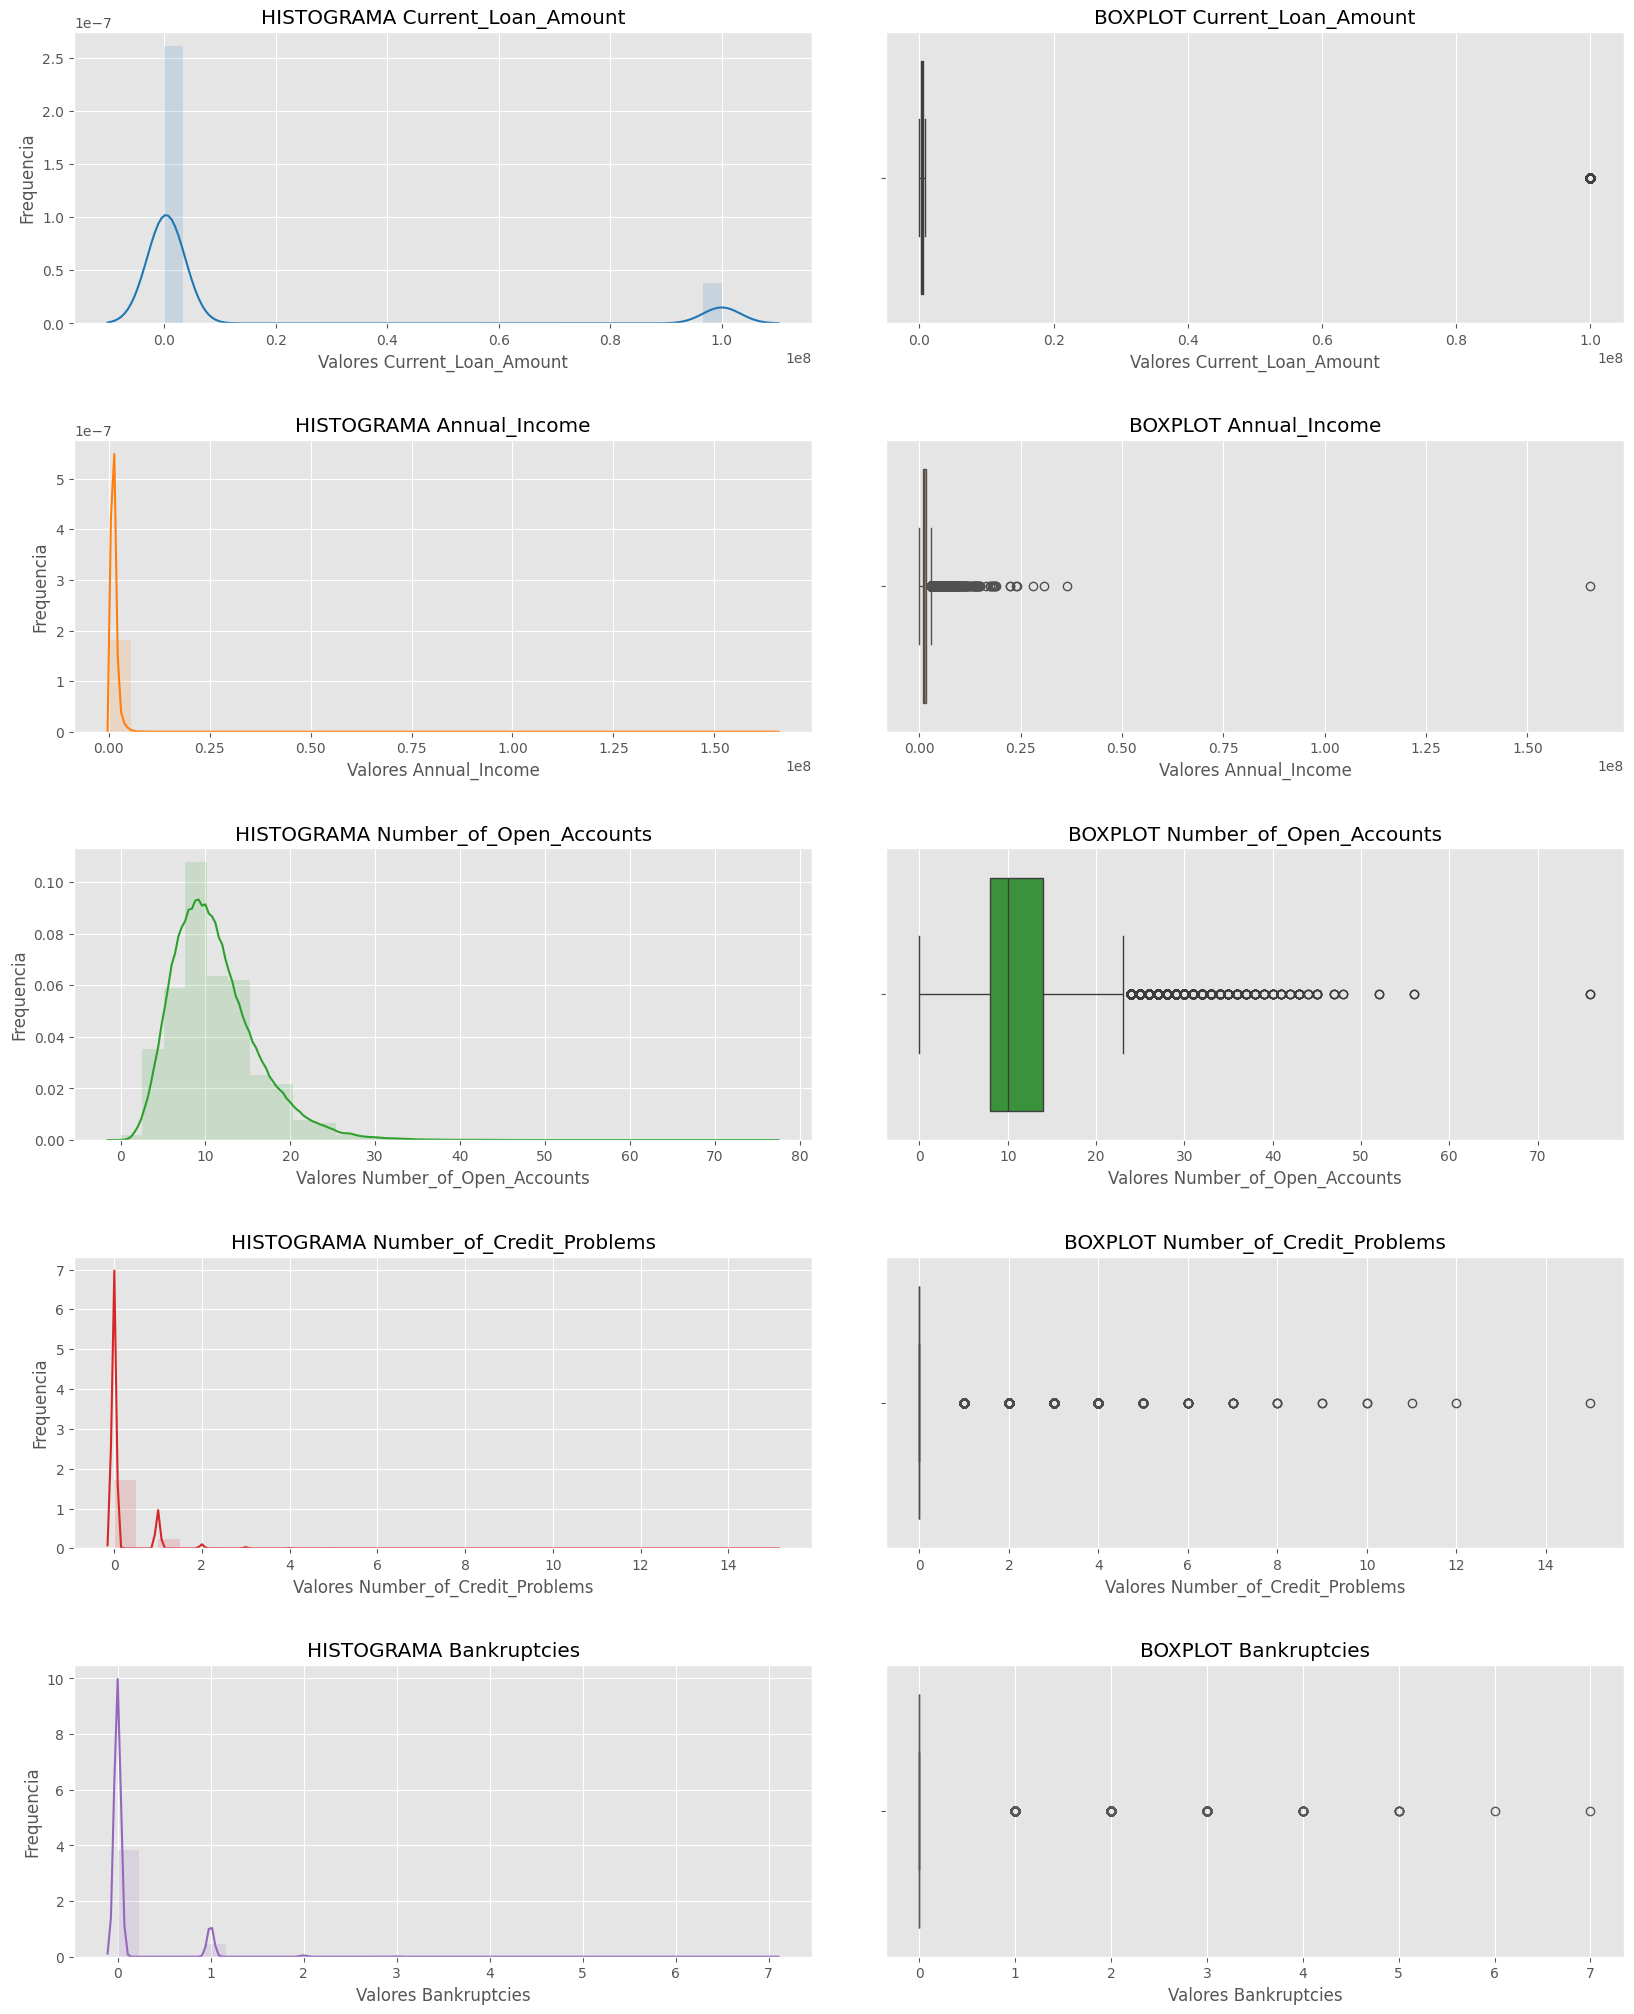

In [49]:
# creamos la grafica
fig, axes = plt.subplots(len(var_num), 2, \
                         figsize=(20, 5 * len(var_num)), \
                         gridspec_kw={'hspace': 0.4, 'wspace': 0.1})
ax = axes.ravel()

# graficas distribucion y boxplot de cada atributo
for idx, atributo in enumerate(var_num):

    # distribucion (histograma)
    sns.distplot(df_loan[atributo], bins=30, ax=ax[2 * idx], \
                 color=TABLEAU_CMP[idx % len(TABLEAU_CMP)], \
                 hist_kws={'alpha': 0.15})

    # titulo, etiquetas histograma
    ax[2 * idx].set_title(f'HISTOGRAMA {atributo}')
    ax[2 * idx].set_xlabel(f'Valores {atributo}')
    ax[2 * idx].set_ylabel("Frequencia")

    # boxplot
    sns.boxplot(x=atributo, data=df_loan, ax=ax[2 * idx + 1], color=TABLEAU_CMP[idx % len(TABLEAU_CMP)])

    # titulo, etiquetas boxplot
    ax[2 * idx + 1].set_title(f'BOXPLOT {atributo}')
    ax[2 * idx + 1].set_xlabel(f'Valores {atributo}')


# guardamos grafica:
fig.savefig('numericas')

##### Columnas "Problemas credito" y "Bancarrota", sopesar si ampliar rango intercuartilico o incluso eliminar

##### Columna "cantidad credito", inspeccionar fila del único atípico. Mima cuestión para "Ingresos" y "Nº de cuentas, con el añadido de presencia de otros outliers + separados

## UNIDIMENSIONALES CATEGORICOS

In [50]:
len(var_cat)

3

In [51]:
var_cat

['Loan_Status', 'Years_in_current_job', 'Home_Ownership']

In [52]:
colores = sns.color_palette("husl", len(var_cat))


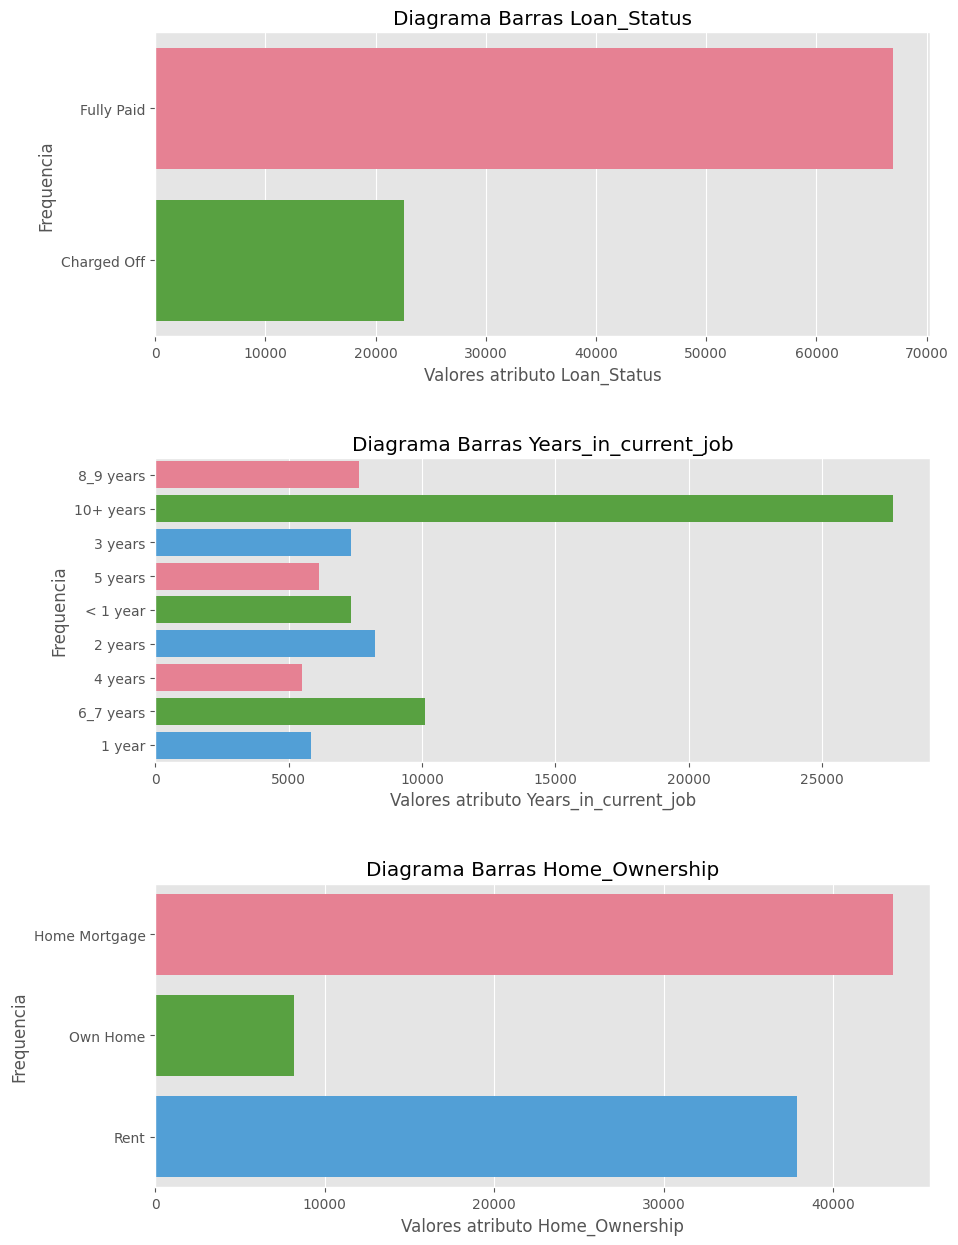

In [72]:
# creacion graficas
fig, axes = plt.subplots(len(var_cat), 1, \
                         figsize=(10, 5*len(var_cat)),\
                         gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

ax = axes.ravel()

# dibujamos las graficas
for idx,variable in enumerate(var_cat):

    # utilizar el método de dibujo que nos interese en cada momento
    # sustituir nombre dataframe y parámetros según método de dibujo

    sns.countplot(df_loan[variable], ax=ax[idx],\
                  palette=colores)

    ax[idx].set_title(f'Diagrama Barras {variable}')
    ax[idx].set_xlabel(f'Valores atributo {variable}')
    ax[idx].set_ylabel("Frequencia")



En esta última llevar a otra categoria o eliminar "haveMortgage"

Ver "Años trabajo" en mas detalle:

In [54]:
columna_anios_ordenada = df_loan.Years_in_current_job.sort_values()

columna_anios_ordenada

,Years_in_current_job
4581,1 year
34636,1 year
68875,1 year
84329,1 year
68884,1 year
...,...
99884,NaN
99895,NaN
99924,NaN
99963,NaN


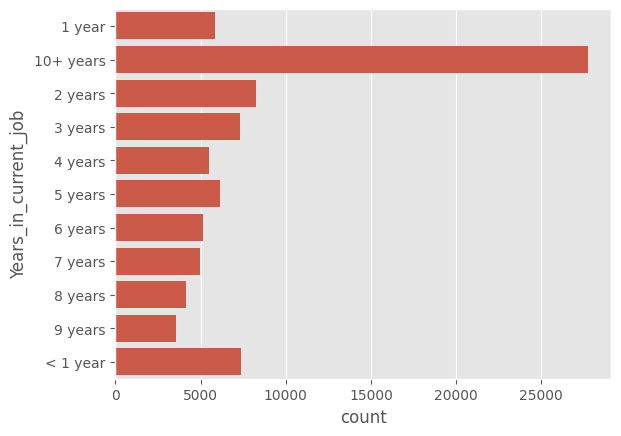

In [55]:
sns.countplot(y=columna_anios_ordenada);

In [56]:
df_loan.Years_in_current_job.unique()

array(['8 years', '10+ years', '3 years', '5 years', '< 1 year',
       '2 years', '4 years', '9 years', '7 years', '1 year', nan,
       '6 years'], dtype=object)

#### Vamos a reorganizar la categórica "Años de antiguedad":

In [57]:
df_loan.Years_in_current_job.replace({'6 years': '6+ years', \
                                      '7 years': '6+ years', \
                                      '8 years': '6+ years', \
                                      '9 years': '6+ years'}).value_counts()


,count
Years_in_current_job,
10+ years,27736
6+ years,17786
2 years,8253
< 1 year,7365
3 years,7337
5 years,6136
1 year,5830
4 years,5510


La nueva categoria es demasiado alto el conteo, con lo cual una agrupacion de pequeños lo convierto en grande: **ERROR, falseo realidad.**

A partir de 6 años, esta vez voy a agrupar de 2 en 2

In [58]:
df_loan.Years_in_current_job.replace({'6 years': '6_7 years', \
                                      '7 years': '6_7 years'}, \
                                    inplace=True)


In [59]:
df_loan.Years_in_current_job.replace({'8 years': '8_9 years', \
                                      '9 years': '8_9 years'}, \
                                    inplace=True)

df_loan.Years_in_current_job.value_counts()


,count
Years_in_current_job,
10+ years,27736
6_7 years,10121
2 years,8253
8_9 years,7665
< 1 year,7365
3 years,7337
5 years,6136
1 year,5830
4 years,5510


### Categoria casi no apreciable "HaveMortgage" en categórica "Home_Ownership"

In [60]:
df_loan.Home_Ownership.value_counts()

,count
Home_Ownership,
Home Mortgage,43530
Rent,37843
Own Home,8198
HaveMortgage,183


In [61]:
df_home_minoritario = df_loan[df_loan.Home_Ownership=='HaveMortgage']

len(df_home_minoritario)

183

**Comparamos distribuciones:**

In [62]:
df_home_minoritario.describe()

,Current_Loan_Amount,Annual_Income,Number_of_Open_Accounts,Number_of_Credit_Problems,Bankruptcies
count,1.830000e+02,1.540000e+02,183.000000,183.000000,182.000000
mean,1.595667e+07,1.389022e+06,10.524590,0.191257,0.137363
std,3.657071e+07,7.317756e+05,4.462074,0.525744,0.345179
min,1.080200e+04,3.783660e+05,3.000000,0.000000,0.000000
25%,6.689100e+04,8.800040e+05,7.000000,0.000000,0.000000
50%,1.241680e+05,1.219610e+06,10.000000,0.000000,0.000000
75%,2.220680e+05,1.652948e+06,13.000000,0.000000,0.000000
max,1.000000e+08,4.340417e+06,24.000000,5.000000,1.000000


In [63]:
df_loan.describe()

,Current_Loan_Amount,Annual_Income,Number_of_Open_Accounts,Number_of_Credit_Problems,Bankruptcies
count,8.975400e+04,7.062200e+04,89754.000000,89754.000000,89564.00000
mean,1.305642e+07,1.375883e+06,11.123482,0.165029,0.11556
std,3.329056e+07,1.104904e+06,4.999313,0.478075,0.34796
min,1.080200e+04,7.662700e+04,0.000000,0.000000,0.00000
25%,1.802680e+05,8.478845e+05,8.000000,0.000000,0.00000
50%,3.138740e+05,1.168908e+06,10.000000,0.000000,0.00000
75%,5.323670e+05,1.648915e+06,14.000000,0.000000,0.00000
max,1.000000e+08,1.655574e+08,76.000000,15.000000,7.00000


Alguna diferencia mínima, acaso estariamos eliminando de outliers. Veamos el target:

In [64]:
df_home_minoritario.Loan_Status.value_counts()

,count
Loan_Status,
Fully Paid,152
Charged Off,31


De nuevo mayoritaria "Fully Paid" y separada.
#### Vamos entonces a eliminar las filas de esa categoria minima:

<Axes: xlabel='count', ylabel='Home_Ownership'>

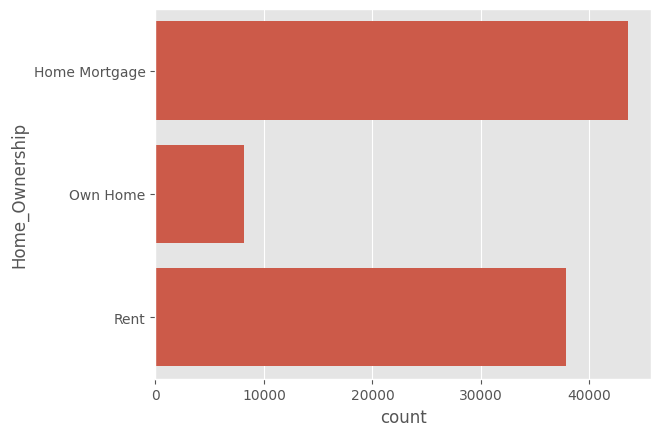

In [65]:
df_loan = df_loan.drop(index=df_loan[df_loan.Home_Ownership=='HaveMortgage'].index)

sns.countplot(df_loan.Home_Ownership)

In [66]:
len(df_loan)

89571

## ANÁLISIS BIDIMENSIONAL

### Categórico-categorico.

In [67]:
var_cat

['Loan_Status', 'Years_in_current_job', 'Home_Ownership']

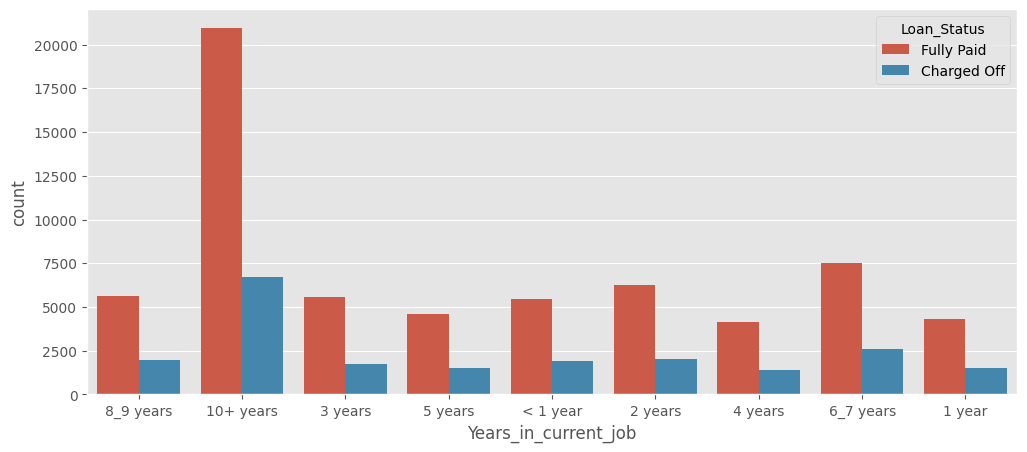

In [68]:
fig, ax = plt.subplots(figsize=(12,5))

sns.countplot(x='Years_in_current_job', hue='Loan_Status', \
              data=df_loan);

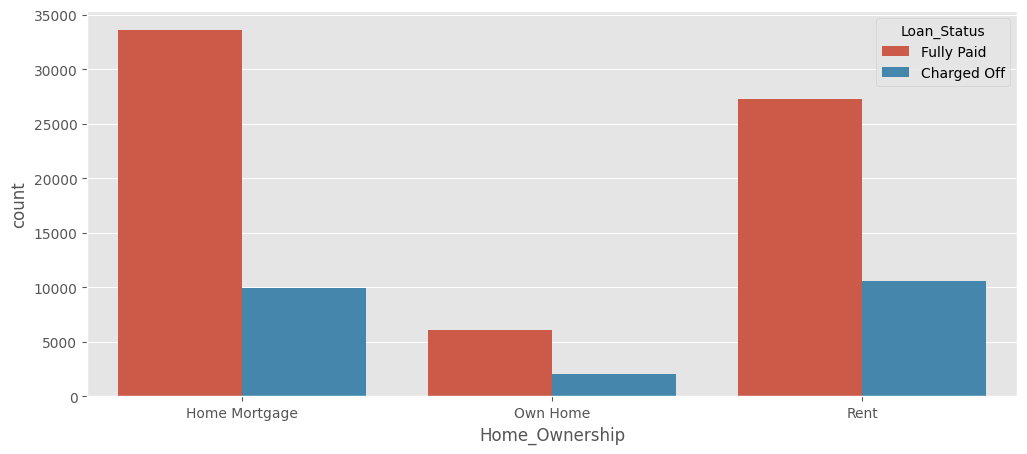

In [69]:
fig, ax = plt.subplots(figsize=(12,5))

sns.countplot(x='Home_Ownership', hue='Loan_Status', \
              data=df_loan);

Parece que **"antiguedad trabajo" no tendria influencia en el target, sin embargo "Home Ownership" si.**

### Numérico-numérico.

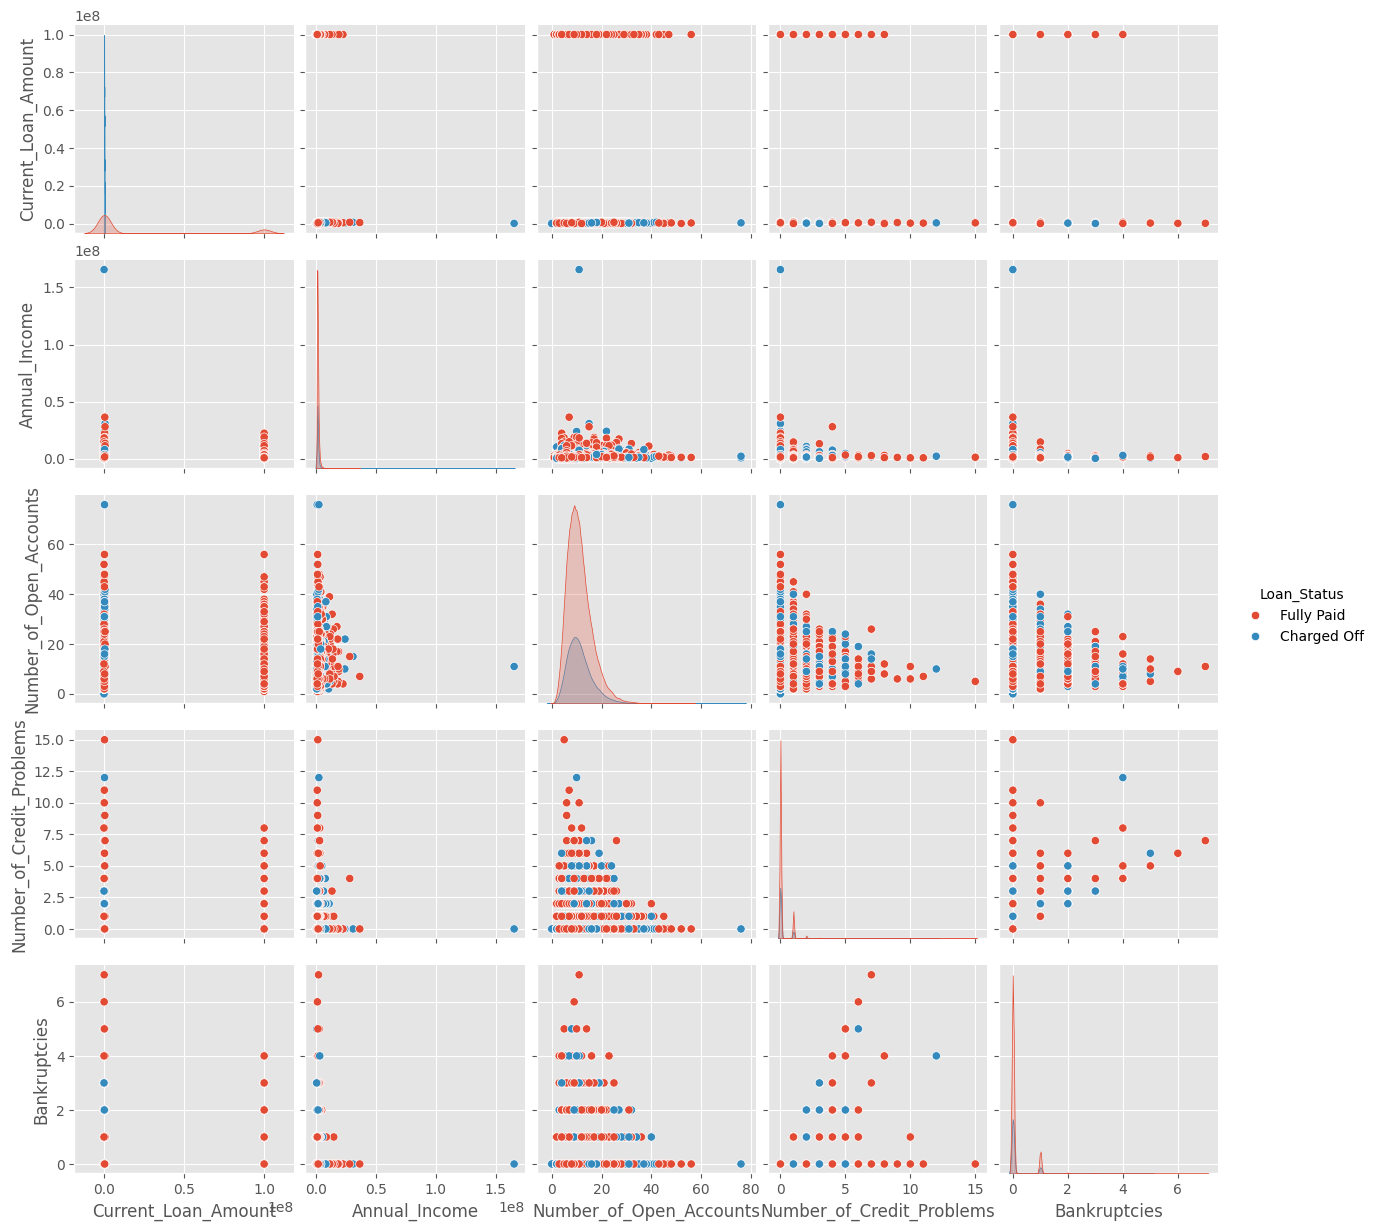

In [70]:
sns.pairplot(data=df_loan, hue='Loan_Status', diag_kind='kde');

In [73]:
# recuerden 'numeric_only=True'
mat_corr = df_loan.corr(numeric_only=True)

mat_corr

,Current_Loan_Amount,Annual_Income,Number_of_Open_Accounts,Number_of_Credit_Problems,Bankruptcies
Current_Loan_Amount,1.000000,0.014649,0.002057,-0.000183,0.001908
Annual_Income,0.014649,1.000000,0.142306,-0.016472,-0.046825
Number_of_Open_Accounts,0.002057,0.142306,1.000000,-0.015325,-0.025677
Number_of_Credit_Problems,-0.000183,-0.016472,-0.015325,1.000000,0.753139
Bankruptcies,0.001908,-0.046825,-0.025677,0.753139,1.000000


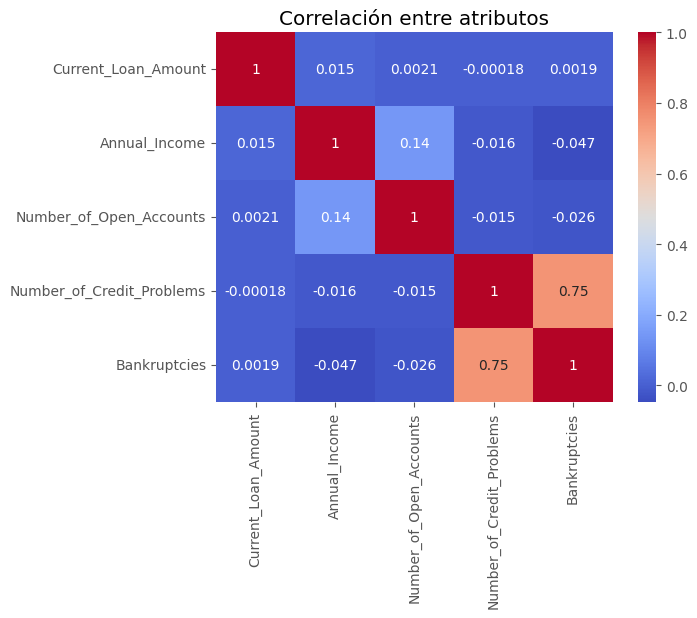

In [74]:
sns.heatmap(mat_corr, annot=True, cbar=True, \
            cmap=sns.color_palette("coolwarm", as_cmap=True))
plt.title('Correlación entre atributos');

**Poco que decir, acaso la  esperada entre Problemas Crediticios y Bancarrotas. Podríamos eliminar una de ellas**

**OJO**: Información de la diagonal del pairplot

### Numérico-categorico.

In [75]:
var_num

['Current_Loan_Amount',
 'Annual_Income',
 'Number_of_Open_Accounts',
 'Number_of_Credit_Problems',
 'Bankruptcies']

In [76]:
var_cat

['Loan_Status', 'Years_in_current_job', 'Home_Ownership']

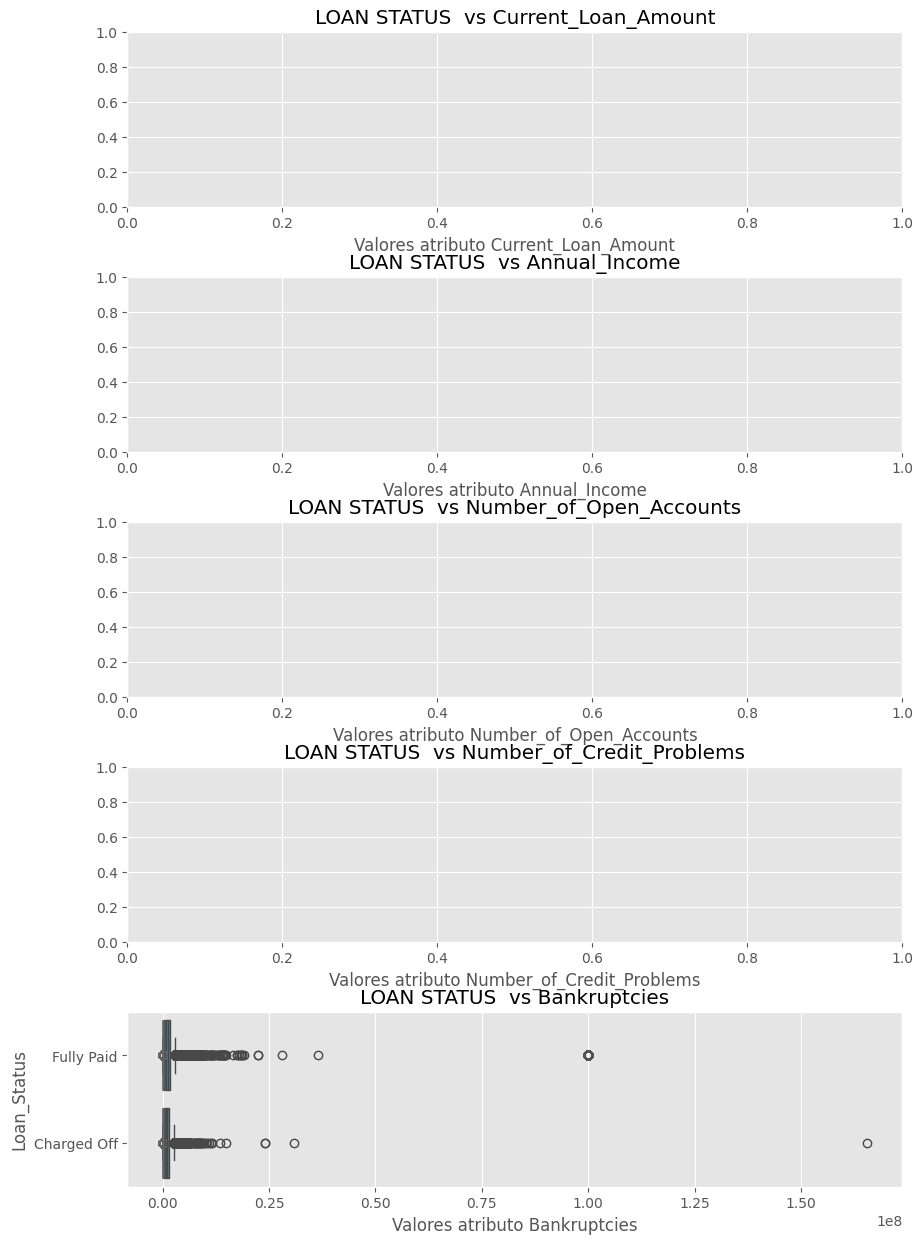

In [77]:
fig, axes = plt.subplots(len(var_num), 1, figsize=(10, 3*len(var_num)), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

ax = axes.ravel()

# dibujamos las graficas
for idx,variable in enumerate(var_num):

    sns.boxplot(data=df_loan, x=variable, y='Loan_Status')

    ax[idx].set_title(f'LOAN STATUS  vs {variable}')
    ax[idx].set_xlabel(f'Valores atributo {variable}')


#### Habremos de esperar a corregir los outliers para el bidimensional numérico-categorico